# RQ3: Human vs. Model bbox annotation

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _rq3_helpers as rq3

SURVEY_CSV = "VLM Survey - responses.csv"
EMMT_ROOT = "/home/oliver/PycharmProjects/EMMT_Survey"
MMM_RESULTS_ROOT = "../defaults/mmm/results"


## Load survey

In [2]:
df_valid = rq3.load_survey(SURVEY_CSV)
df_valid.shape


(3023, 19)

## Case metadata (authoritative model/modality/ground truth per case)

In [3]:
case_meta = rq3.load_case_metadata(EMMT_ROOT)
case_lookup = rq3.load_case_lookup(EMMT_ROOT)


## Human IoU

In [4]:
human_iou = rq3.compute_human_task_iou(df_valid, case_lookup, case_meta)
print(f"{len(human_iou)} / {len(df_valid)} rows joined to a case")
human_iou[human_iou["interpretable"]].groupby("category")["iou"].agg(["mean", "std", "count"])


3023 / 3023 rows joined to a case


,mean,std,count
category,,,
multi,0.442665,0.246737,534
single/multi,0.462268,0.254696,480
single/solo,0.681990,0.242773,529
udacity,0.504018,0.280540,488


In [5]:
human_iou.groupby("category")["iou_adjusted"].agg(["mean", "std", "count"])


,mean,std,count
category,,,
multi,0.312676,0.289269,756
single/multi,0.293504,0.301255,756
single/solo,0.477212,0.372921,756
udacity,0.325776,0.330117,755


## Reject / skip fractions by category

In [6]:
rq3.reject_skip_fractions(df_valid)


,n_rows,frac_reject_unclear_image,frac_reject_unclear_label,frac_reject_other,frac_skip
category,,,,,
multi,756.0,0.116402,0.136243,0.013228,0.027778
single/multi,756.0,0.141534,0.167989,0.014550,0.041005
single/solo,756.0,0.113757,0.149471,0.005291,0.031746
udacity,755.0,0.147020,0.152318,0.025166,0.029139


## Case-level acceptance consensus

In [7]:
case_df = rq3.case_human_iou(human_iou)
case_df.head()


,model,modality,category,n_raters,n_accept,accept_rate,iou_given_accept,iou_robust,consensus
case_id,,,,,,,,,
case_001,nemotron,unimodal/image,single/solo,12,5,0.416667,0.729165,0.303819,split
case_002,nemotron,unimodal/image,single/solo,24,9,0.375000,0.554440,0.207915,split
case_003,nemotron,unimodal/image,single/solo,27,16,0.592593,0.640043,0.379285,split
case_004,nemotron,unimodal/text,single/solo,27,11,0.407407,0.287514,0.117135,split
case_005,nemotron,unimodal/text,single/solo,24,16,0.666667,0.741248,0.494166,split


In [8]:
rq3.acceptance_consensus(case_df, "category")


,n_cases,mean_accept_rate,frac_unanimous_accept,frac_split,frac_unanimous_reject
category,,,,,
multi,36.0,0.705890,0.000000,1.000000,0.0
single/multi,36.0,0.641718,0.027778,0.972222,0.0
single/solo,36.0,0.698688,0.083333,0.916667,0.0
udacity,36.0,0.653468,0.055556,0.944444,0.0


In [9]:
rq3.acceptance_consensus(case_df, "model")

,n_cases,mean_accept_rate,frac_unanimous_accept,frac_split,frac_unanimous_reject
model,,,,,
intern,36.0,0.706147,0.000000,1.000000,0.0
kimi,36.0,0.758663,0.083333,0.916667,0.0
nemotron,36.0,0.602238,0.027778,0.972222,0.0
qwen,36.0,0.632716,0.055556,0.944444,0.0


## Interrater agreement (Krippendorff's alpha, 3-class)

In [10]:
pd.DataFrame(rq3.krippendorff_alpha_by_category(df_valid)).T


,alpha,n_items
overall,0.08651,127.0
multi,-0.00640,34.0
single/multi,0.08137,33.0
single/solo,0.08326,33.0
udacity,0.16814,27.0


## Model final IoU, full population, by model / modality / category

In [11]:
model_iou_full = rq3.load_model_results(MMM_RESULTS_ROOT)
model_iou_full.assign(model=model_iou_full["model"].map(rq3.MODEL_LABELS)).groupby(
    ["model", "modality", "category"]
)["iou"].agg(["mean", "std", "count"])


mean       std  count
model        modality       category                               
InternVL-3.5 multimodal     multi         0.074941  0.110595    100
                            single/multi  0.039124  0.068513    100
                            single/solo   0.034167  0.072540    100
                            udacity       0.010184  0.047335     56
             unimodal/image multi         0.087553  0.129217    100
                            single/multi  0.050170  0.097172    100
                            single/solo   0.048445  0.103929    100
                            udacity       0.009733  0.040994     56
             unimodal/text  multi         0.082515  0.122494    100
                            single/multi  0.041504  0.074412    100
                            single/solo   0.035632  0.085117    100
                            udacity       0.001134  0.006754     56
Kimi-VL      multimodal     multi         0.012154  0.060819    100
                            single/multi  0.016044  0.073891    100
                            single/solo   0.016224  0.073148    100
                            udacity       0.000648  0.004054     56
             unimodal/image multi         0.023263  0.109323    100
                            single/multi  0.015489  0.072326    100
                            single/solo   0.040823  0.131531    100
                            udacity       0.000200  0.001494     56
             unimodal/text  multi         0.006168  0.040998    100
                            single/multi  0.004672  0.046724    100
                            single/solo   0.020254  0.081318    100
                            udacity       0.000000  0.000000     56
Nemotron3-ON multimodal     multi         0.106734  0.168889    100
                            single/multi  0.013026  0.091066    100
                            single/solo   0.073152  0.160922    100
                            udacity       0.013008  0.043290     56
             unimodal/image multi         0.151587  0.221520    100
                            single/multi  0.035112  0.137689    100
                            single/solo   0.412319  0.228324    100
                            udacity       0.053654  0.127755     56
             unimodal/text  multi         0.093915  0.167276    100
                            single/multi  0.013382  0.096593    100
                            single/solo   0.002003  0.014837    100
                            udacity       0.011027  0.048252     56
Qwen3-VL     multimodal     multi         0.183662  0.198902    100
                            single/multi  0.053127  0.119051    100
                            single/solo   0.051559  0.140419    100
                            udacity       0.004889  0.026222     56
             unimodal/image multi         0.385043  0.319964    100
                            single/multi  0.423950  0.309098    100
                            single/solo   0.611005  0.239326    100
                            udacity       0.070894  0.191981     56
             unimodal/text  multi         0.217612  0.210484    100
                            single/multi  0.083605  0.207551    100
                            single/solo   0.057419  0.173223    100
                            udacity       0.003861  0.028047     56

In [12]:
model_iou_cases = rq3.case_model_iou(case_meta)
model_iou_cases.assign(model=model_iou_cases["model"].map(rq3.MODEL_LABELS)).groupby(["model", "modality"])[
    "iou"
].agg(["count"])


count
model        modality             
InternVL-3.5 multimodal         12
             unimodal/image     12
             unimodal/text      12
Kimi-VL      multimodal         12
             unimodal/image     12
             unimodal/text      12
Nemotron3-ON multimodal         12
             unimodal/image     12
             unimodal/text      12
Qwen3-VL     multimodal         12
             unimodal/image     12
             unimodal/text      12

## Human vs. model Mean IoU, grouped by model

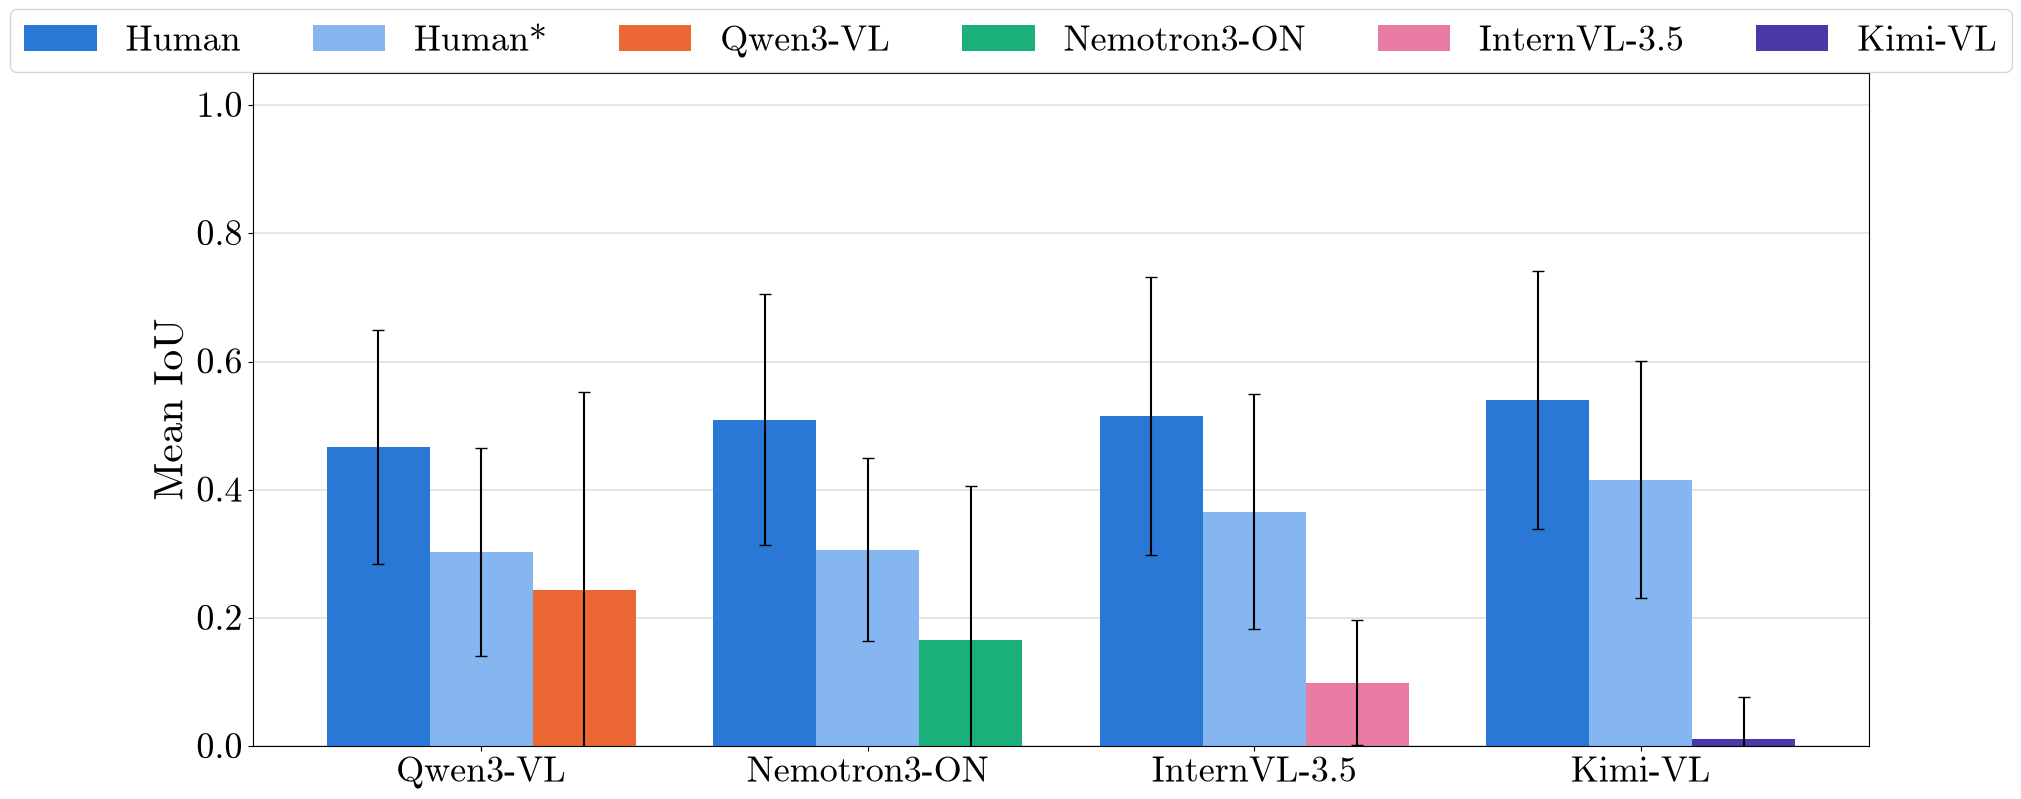

In [13]:
from matplotlib.patches import Patch

MODEL_ORDER = rq3.MODELS
MODEL_COLORS = {"qwen": "#eb6834", "nemotron": "#1baf7a", "intern": "#e87ba4", "kimi": "#4a3aa7"}
HUMAN_COLOR, HUMAN_ADJ_COLOR = "#2a78d6", "#86b6ef"

FONT = {
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "DejaVu Serif"],
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 28,
    "axes.titlesize": 34,
    "axes.labelsize": 30,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26,
}

stats = case_df.groupby("model").agg(
    human_mean=("iou_given_accept", "mean"),
    human_std=("iou_given_accept", "std"),
    human_n=("iou_given_accept", "count"),
    robust_mean=("iou_robust", "mean"),
    robust_std=("iou_robust", "std"),
)
model_stats = model_iou_cases.groupby("model")["iou"].agg(model_mean="mean", model_std="std", model_n="count")
stats = stats.join(model_stats)

with plt.rc_context(FONT):
    fig, ax = plt.subplots(figsize=(4.5 * len(MODEL_ORDER), 8))

    x = np.arange(len(MODEL_ORDER))
    bar_w = 0.8 / 3
    series = [
        ("Human", "human_mean", "human_std", "human_n", HUMAN_COLOR),
        ("Human*", "robust_mean", "robust_std", None, HUMAN_ADJ_COLOR),
        ("Model", "model_mean", "model_std", "model_n", None),
    ]
    for i, (name, mean_col, std_col, n_col, color) in enumerate(series):
        vals = [stats.loc[m, mean_col] for m in MODEL_ORDER]
        errs = [stats.loc[m, std_col] for m in MODEL_ORDER]
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER] if color is None else color
        ax.bar(x + (i - 1) * bar_w, vals, width=bar_w, yerr=errs, capsize=4, color=colors, zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels([rq3.MODEL_LABELS[m] for m in MODEL_ORDER])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean IoU")
    ax.grid(axis="y", color="#e1e0d9", linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)

    legend_handles = [
        Patch(facecolor=HUMAN_COLOR, label="Human"),
        Patch(facecolor=HUMAN_ADJ_COLOR, label="Human*"),
    ] + [Patch(facecolor=MODEL_COLORS[m], label=rq3.MODEL_LABELS[m]) for m in MODEL_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout()
    fig.savefig("figures/rq3_human_vs_model_iou.pdf", dpi=200, bbox_inches="tight")
    plt.show()
